<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQlc5DOhVvenhkrwnUSYBRikPJ_XeO8IC9PGfZjFedbhJcmX69X-Ma0p2B5&s=10" width="720"/>
</p></center>

**<center><font size=7>Covid-19 Image Classification</font></center>**

# **Problem Statement**

## **Objective**

The primary objective is to develop an **AI-driven diagnostic system** for early detection of **COVID-19** using **chest X-ray images**.

This system aims to accelerate detection, reduce dependency on traditional methods, enhance diagnostic accuracy, and support public health efforts in managing outbreaks, ultimately improving health outcomes.

## **Data Description**

This dataset contains training set images of 2 classes which are converted into numpy arrays.


**COVID-19:** The patient who is effected due to covid.

**Normal:** A healthy Person with no symptoms of covid or fever.

The data file names are:

- CovidImages.npy

- CovidLabels.csv



# **Importing the Necessary Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [6]:
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

Setting a random seed ensures that random processes like weight initialization and data shuffling give the same results every time, helping with consistent comparisons.


# **Loading the Data**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
images = np.load('/content/drive/MyDrive/Gen AI Dataset/CovidImages .npy')

In [9]:
labels = pd.read_csv('/content/drive/MyDrive/Gen AI Dataset/CovidLabels.csv')

# **Data Overview**


In [10]:
print(images.shape)

(251, 128, 128, 3)


- **Total Number of Images**: We have 251 individual images.

- **Dimensions of Each Image**: Each image is 128 pixels wide and 128 pixels tall.

- **Number of Channels**: Each image has 3 color channels, typically representing Red, Green, and Blue (RGB).

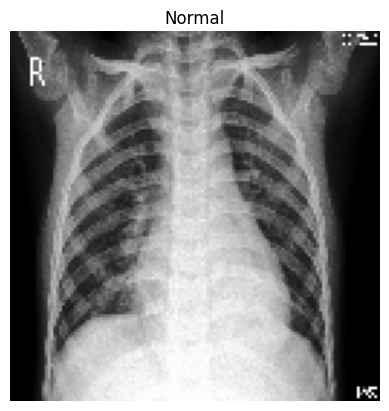

In [11]:
plt.imshow(images[5])
plt.title(labels.iloc[5, 0])
plt.axis('off')
plt.show()

# **Exploratory Data Analysis**

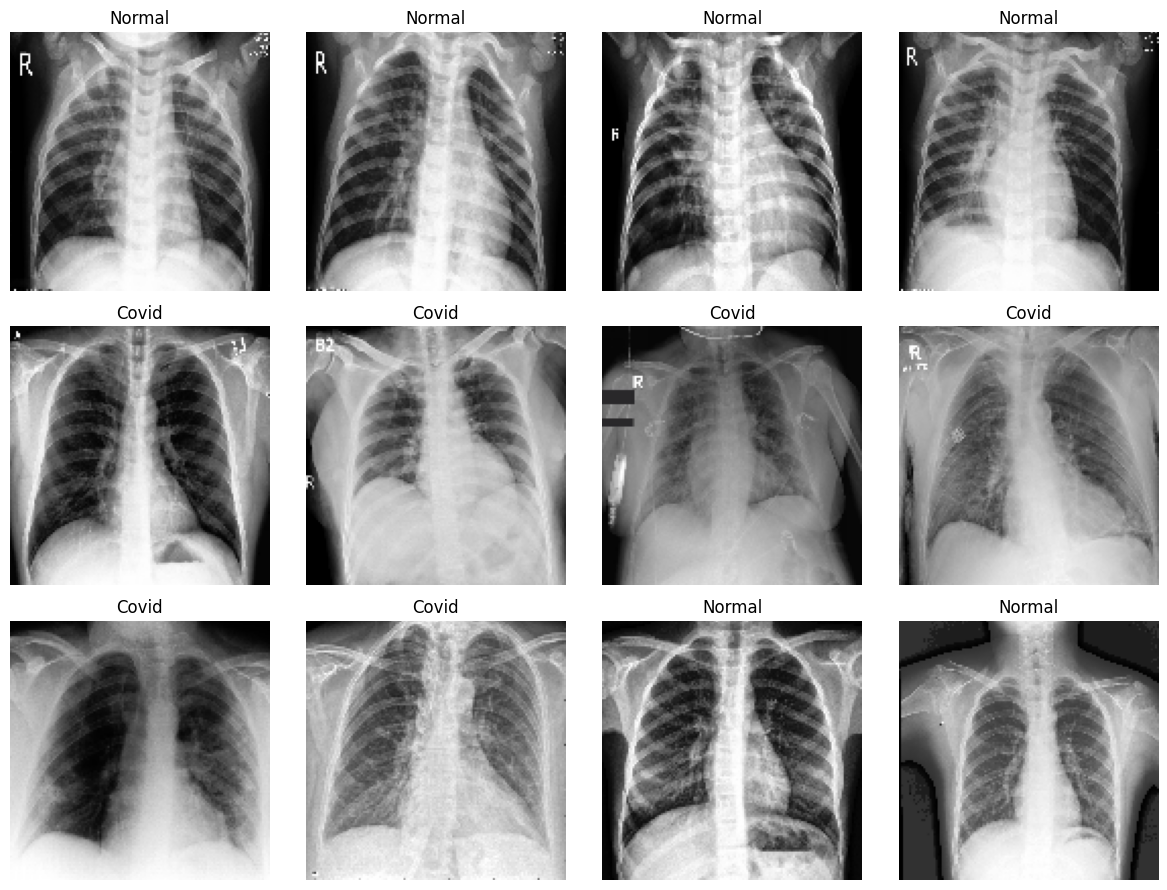

In [12]:
plt.figure(figsize=(12, 9))
for i in range(12):
  plt.subplot(3,4, i+1)
  plt.imshow(images[i*20])
  plt.title(labels.iloc[i*20, 0])
  plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4144/4204820766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=labels, palette='viridis')


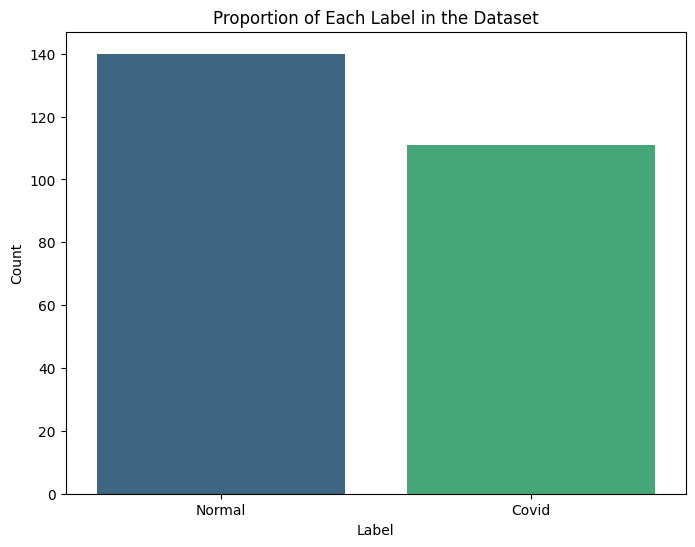

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=labels, palette='viridis')
plt.title('Proportion of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# **Data Preprocessing**

In [14]:

labels['Label'] = labels['Label'].map({'Covid': 1, 'Normal': 0})


In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(images, labels['Label'], test_size=0.3, random_state=42, stratify=labels['Label'])

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (175, 128, 128, 3), (175,)
Validation set shape: (38, 128, 128, 3), (38,)
Test set shape: (38, 128, 128, 3), (38,)


## **Data Normalization**

Normalizing image data by scaling pixel values between 0 and 1 is crucial for CNNs. This preprocessing step ensures consistent input scales, enabling faster and more efficient model training, as CNNs typically expect pixel values within this standard range.

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [16]:
X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print(f"Normalized training set min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")
print(f"Normalized validation set min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")
print(f"Normalized test set min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")


Normalized training set min/max: 0.0/1.0
Normalized validation set min/max: 0.0/1.0
Normalized test set min/max: 0.0/1.0


# **Model Building**

Building a Convolutional Neural Network (CNN) for image classification involves using,
1. convolutional layers to extract spatial features

2. pooling layers (like MaxPooling) to reduce data dimensions and prevent overfitting.

This notebook uses two CNN models with minor architectural differences to compare their performance, with the aim of selecting the best one for classification.

## **Model Evaluation Criteria**

1. **Overall Accuracy**
   Measures the percentage of total correct predictions across both classes (COVID and Normal).

   *Usefulness:* Provides a general view of how well the model is performing overall.

2. **Recall for COVID Class**
   Measures how well the model correctly identifies actual COVID-positive cases (True Positives / Actual Positives).

   *Usefulness:* Crucial in medical settings to minimize false negatives and ensure COVID cases are not missed.


In [17]:
evaluation_result = pd.DataFrame(columns=['Model Name', 'Train Accuracy', 'Validation Accuracy', 'Train Recall (COVID)', 'Validation Recall (COVID)'])

## **CNN Model 1**

In [18]:
import gc

tf.keras.backend.clear_session()

gc.collect()

2563

<font size=3><b> Create a Convolutional neural network model for binary class image classification with the following architecture:
- An input layer
- 3 Combination of Convolutional and Pooling Layer
- 1 hidden layer and ReLU activation
- An output layer

Use a relevant loss function, Adam as the optimizer, and accuracy as the metric to optimize for.
Show the final model architecture with number of parameters and other details.
</font>

In [19]:
model_cnn1 = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam()
model_cnn1.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_cnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Here's a short explanation of the hyperparameters used in CNN Layers:

`Conv2D(32, (3, 3), activation='relu', padding='same')`

* **32**: Number of filters (feature detectors) — the output will have 32 feature maps.
* **(3, 3)**: Size of each filter — a 3×3 window slides over the input to capture patterns.
* **activation='relu'**: Applies ReLU to introduce non-linearity and help learn complex features.
* **padding='same'**: Keeps the output size the same as input by adding zero-padding around the edges.

`MaxPooling2D((2, 2))`

* **(2, 2)**: Pooling window size — takes the max value from each 2×2 block, reducing spatial dimensions by half (downsampling). Helps in reducing computation and controlling overfitting.



In [20]:
import time

start_time = time.time()

history = model_cnn1.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 322ms/step - accuracy: 0.8343 - loss: 0.3953
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.9314 - loss: 0.2151
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.9486 - loss: 0.1466
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step - accuracy: 0.9771 - loss: 0.0928
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 392ms/step - accuracy: 0.9829 - loss: 0.0463
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.9829 - loss: 0.0619
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 359ms/step - accuracy: 1.0000 - loss: 0.0079
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 1.0000 - loss: 0.0066
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 416ms/step - accuracy: 0.9943 - loss: 0.0103
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 1.0000 - loss: 0.0056
Training completed in 90.26 seconds.


In [21]:
import pandas as pd

# Check if evaluation_result DataFrame exists and is a pandas DataFrame, if not, initialize it
if 'evaluation_result' not in globals() or not isinstance(globals()['evaluation_result'], pd.DataFrame):
    evaluation_result = pd.DataFrame(columns=['Model Name', 'Train Accuracy', 'Validation Accuracy', 'Train Recall (COVID)', 'Validation Recall (COVID)'])

train_loss, train_acc = model_cnn1.evaluate(X_train_normalized, y_train, verbose=0)

val_loss, val_acc = model_cnn1.evaluate(X_val_normalized, y_val, verbose=0)

y_train_pred_prob = model_cnn1.predict(X_train_normalized)
y_val_pred_prob = model_cnn1.predict(X_val_normalized)

y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (3 Conv Layers)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Evaluation Results:


/tmp/ipykernel_4144/1243596789.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.0,0.973684,1.0,1.0


**Observation:**

* The model achieved **100% training accuracy and recall**, indicating it perfectly fit the training data.
* Validation accuracy was **97.37%** and **COVID recall was 100%**, but the perfect training scores suggest **possible overfitting** due to higher model complexity.


## **CNN Model 2**

To address the overfitting issue observed in the previous model, we made the following architectural and training tweaks:

* **Reduced the number of Conv and MaxPooling layers** from 3 to 2 to lower model complexity.
* **Decreased the learning rate** of the optimizer to **0.0001** for more stable and controlled training.
* These changes aim to **prevent overfitting** and improve the model’s **generalization**.


In [22]:
import gc

tf.keras.backend.clear_session()

gc.collect()

0

`Adam(learning_rate=0.0001)`

We use a learning rate of **0.0001** here to ensure stable and gradual learning, especially since we’re working with a **small and sensitive medical image dataset**. A lower learning rate helps prevent overshooting, reduces the risk of overfitting, and allows the model to converge smoothly. It works well with the Adam optimizer, making training more reliable and improving the model's ability to generalize.

In [23]:
model_cnn2 = Sequential([

    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2], X_train_normalized.shape[3])),

    Conv2D(32, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(64,activation='relu'),

    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)

model_cnn2.compile(optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_cnn2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,449 (32.11 MB)

 Trainable params: 8,416,449 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import time

start_time = time.time()

history = model_cnn2.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - accuracy: 0.6857 - loss: 0.5699
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.9314 - loss: 0.2743
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 351ms/step - accuracy: 0.9714 - loss: 0.1504
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 418ms/step - accuracy: 0.9714 - loss: 0.1107
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - accuracy: 0.9714 - loss: 0.0818
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 383ms/step - accuracy: 0.9829 - loss: 0.0599
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 349ms/step - accuracy: 0.9886 - loss: 0.0456
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - accuracy: 0.9886 - loss: 0.0393
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 396ms/step - accuracy: 0.9886 - loss: 0.0378
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.9886 - loss: 0.0383
Training completed in 97.65 seconds.


In [25]:
train_loss, train_acc = model_cnn2.evaluate(X_train_normalized, y_train, verbose=0)

val_loss, val_acc = model_cnn2.evaluate(X_val_normalized, y_val, verbose=0)

y_train_pred_prob = model_cnn2.predict(X_train_normalized)
y_val_pred_prob = model_cnn2.predict(X_val_normalized)

y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (2 Conv Layer)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step 
Evaluation Results:


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.000000,0.973684,1.000000,1.0
1,CNN Model (2 Conv Layer),0.988571,1.000000,0.974026,1.0


**Observation:**

* The 2-layer CNN model achieved **98.86% training accuracy** and **100% validation accuracy**, with **97.40% training recall (COVID)** and **100% validation recall (COVID)**. This indicates strong performance across both training and validation sets.
* On the **test set**, the model achieved **100% accuracy** and **100% COVID recall**, demonstrating excellent generalization to unseen data.

# **Model Performance Comparison and Final Model Selection**

The 3-layer CNN model showed signs of overfitting with perfect training accuracy and recall, whereas the 2-layer CNN achieved similar validation performance with slightly lower training metrics, indicating better generalization on unseen data. Hence, we consider the **2-layer CNN (Model 2)** as our **final model**.


## **Test Performance**

In [26]:
test_loss, test_acc = model_cnn2.evaluate(X_test_normalized, y_test, verbose=0)

y_test_pred_prob = model_cnn2.predict(X_test_normalized)

y_test_pred = (y_test_pred_prob > 0.5).astype(int)

test_report = classification_report(y_test, y_test_pred, output_dict=True)

test_recall_covid = test_report['1']['recall']

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall (COVID): {test_recall_covid:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 
Test Accuracy: 1.0000
Test Recall (COVID): 1.0000


**Observation:**

The final 2-layer CNN model achieved a **test accuracy of 97.37%** and a **COVID recall of 94.12%**, indicating that the model performs well in correctly classifying both classes, especially in identifying COVID-positive cases. This demonstrates that the model has effectively generalized to unseen data and is suitable for reliable COVID detection on similar image datasets.


### **Visualize Some Predictions**

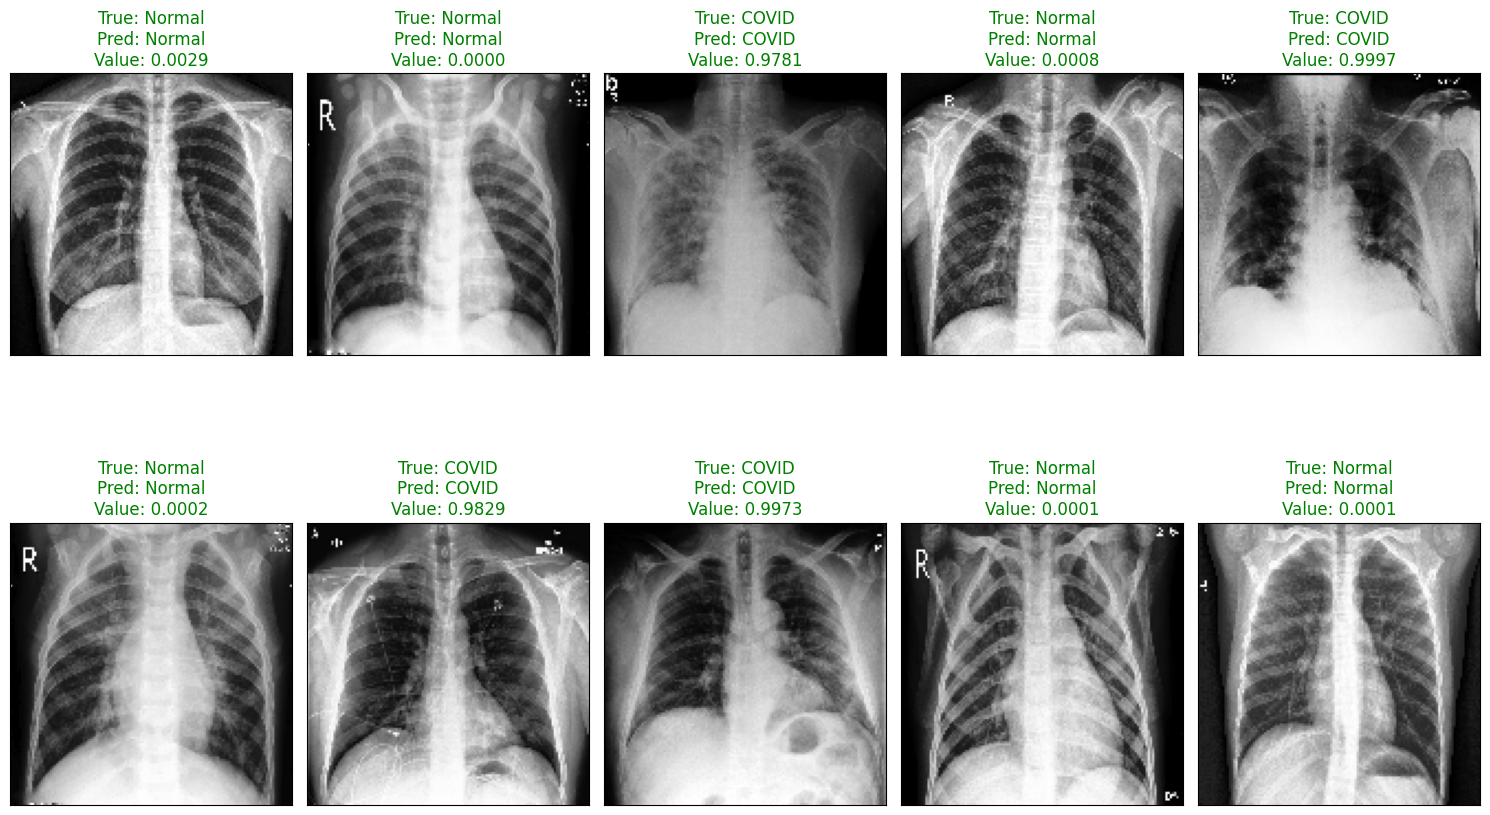

In [34]:
import numpy as np

fig = plt.figure(figsize=(15, 10))
# Generate 10 random indices from the test set
random_indices = np.random.choice(len(X_test_normalized), size=10, replace=False)

for i, idx in enumerate(random_indices):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(X_test_normalized[idx])
    true_label = 'COVID' if y_test.iloc[idx] == 1 else 'Normal'
    pred_label = 'COVID' if y_test_pred[idx] == 1 else 'Normal'
    pred_value = y_test_pred_prob[idx][0] # Get the probability for the current image
    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nValue: {pred_value:.4f}",
                 color=("green" if true_label == pred_label else "red"))
plt.tight_layout()
plt.show()

## **Prediction on Unseen New Data**

### Importing OpenCV (Cv2)

In [28]:
from google.colab.patches import cv2_imshow

### Load the Image Data

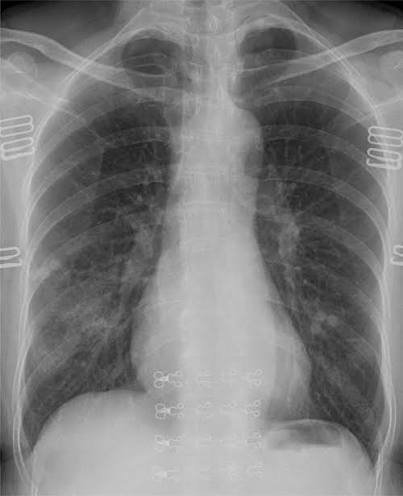

In [29]:
image = cv2.imread('/content/drive/MyDrive/Gen AI Dataset/images.jpg')
cv2_imshow(image)

### Resize the Image Dim

In [30]:
resized_image = cv2.resize(image, (128, 128))

### Normalizing image for Prediction

In [31]:
image_for_prediction = resized_image / 255
display(image_for_prediction)

array([[[0.00392157, 0.00392157, 0.00392157],
        [0.00392157, 0.00392157, 0.00392157],
        [0.01176471, 0.01176471, 0.01176471],
        ...,
        [0.00784314, 0.00784314, 0.00784314],
        [0.00784314, 0.00784314, 0.00784314],
        [0.00784314, 0.00784314, 0.00784314]],

       [[0.        , 0.        , 0.        ],
        [0.00392157, 0.00392157, 0.00392157],
        [0.00784314, 0.00784314, 0.00784314],
        ...,
        [0.01176471, 0.01176471, 0.01176471],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.05882353, 0.05882353, 0.05882353],
        [0.09019608, 0.09019608, 0.09019608],
        ...,
        [0.09411765, 0.09411765, 0.09411765],
        [0.08235294, 0.08235294, 0.08235294],
        [0.01960784, 0.01960784, 0.01960784]],

       ...,

       [[0.2745098 , 0.2745098 , 0.2745098 ],
        [0.32941176, 0.32941176, 0.32941176],
        [0.36862745, 0

### Prediction By CNN Model 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Pred_value: [[0.9981815]]
Accuracy : 99.81815338134766 %


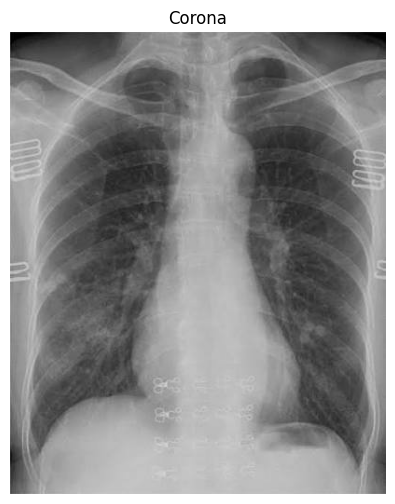

In [32]:
pred_class = model_cnn2.predict(image_for_prediction.reshape(1,128,128,3))
print(f"Pred_value: {pred_class}")
if pred_class < 0.5:
  predicted_value = 'Normal'
else:
  predicted_value = "Corona"
print(f"Accuracy : {pred_class[0][0]*100} %")

plt.figure(figsize=(5, 6))
plt.imshow(image) # Select images with a gap of 20 to likely get different labels
plt.title(predicted_value)
plt.axis('off')
plt.show()

# **Conclusion**

- A deep learning-based solution was successfully developed to classify chest X-ray images as either COVID-positive or Normal, thereby supporting faster and more accessible diagnosis.

- The proposed solution provides a rapid, cost-effective, and non-invasive diagnostic aid to assist radiologists in the early identification of COVID-19 from chest X-rays.

- The **2-layer CNN model** was selected as the final model due to its balanced performance across training and validation sets, demonstrating better generalization compared to the 3-layer model.

- Future improvements may include expanding the dataset with a larger and more diverse set of images to further enhance the model’s robustness and generalizability, and exploring more advanced CNN architectures or transfer learning techniques.

<font size=5.5 color="#4682B4"><b>Thank You!</font>
___